In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (log_loss)
import joblib
from tfm_segunda.evaluate_models import evaluar_modelo, graficar_matriz_confusion
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import xgboost as xgb
import warnings

from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz


warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')
PROJECT_ROOT = Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True, parents=True)
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

In [2]:
dataset_path = DATA_PROCESSED / "dataset_modelado.parquet"
df = pd.read_parquet(dataset_path)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nFilas por split:")
print(df['split'].value_counts())
train = df[df['split'] == 'train'].copy()
validation = df[df['split'] == 'validation'].copy()
test = df[df['split'] == 'test'].copy()

print(f"Train:      {len(train):>5,} filas  |  fechas {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Validation: {len(validation):>5,} filas  |  fechas {validation['date'].min().date()} → {validation['date'].max().date()}")
print(f"Test:       {len(test):>5,} filas  |  fechas {test['date'].min().date()} → {test['date'].max().date()}")
META_COLS = ['split', 'season', 'date', 'jornada', 'home_team', 'away_team', 'fthg', 'ftag']
TARGET_COLS = ['ftr']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS + TARGET_COLS]

Dataset cargado: 7,295 filas × 41 columnas

Filas por split:
split
train         4592
validation    1373
test           923
demo           407
Name: count, dtype: int64
Train:      4,592 filas  |  fechas 2010-08-27 → 2020-08-07
Validation: 1,373 filas  |  fechas 2020-09-12 → 2023-05-28
Test:         923 filas  |  fechas 2023-08-11 → 2025-06-01


In [3]:
def preparar_xy(particion, feature_cols):
    mask_completas = particion[feature_cols].notna().all(axis=1)
    p = particion.loc[mask_completas].copy()
    
    X = p[feature_cols].astype(float)
    y = p['ftr']
    return X, y


X_train, y_train = preparar_xy(train, FEATURE_COLS)
X_val, y_val = preparar_xy(validation, FEATURE_COLS)
X_test, y_test = preparar_xy(test, FEATURE_COLS)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


X_train: (4482, 32), y_train: (4482,)
X_val: (1338, 32), y_val: (1338,)
X_test: (901, 32), y_test: (901,)


In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

le = LabelEncoder().fit(y_train)
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print("Clases:", list(le.classes_))

Clases: ['A', 'D', 'H']


In [ ]:
param_dist = {
    'n_estimators':      randint(200, 1200),
    'max_depth':         randint(2, 8),
    'learning_rate':     uniform(0.01, 0.20),
    'subsample':         uniform(0.6, 0.4),
    'colsample_bytree':  uniform(0.5, 0.5),
    'min_child_weight':  randint(1, 20),
    'gamma':             uniform(0, 0.5),
    'reg_alpha':         uniform(0, 1.0),
    'reg_lambda':        uniform(0.5, 2.0),
}

xgb_base = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
)

rs = RandomizedSearchCV(
    estimator           = xgb_base,
    param_distributions = param_dist,
    n_iter              = 80,
    cv                  = TimeSeriesSplit(n_splits=5),
    scoring             = 'neg_log_loss',
    n_jobs              = -1,
    verbose             = 1,
    refit               = True,
    random_state        = SEED,
)
rs.fit(X_train, y_train_enc)
print("Mejores params (simple):", rs.best_params_)
print(f"Mejor log-loss CV: {-rs.best_score_:.4f}")


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Mejores params (simple): {'colsample_bytree': np.float64(0.7237061834117273), 'gamma': np.float64(0.2663086332275116), 'learning_rate': np.float64(0.058494100726945934), 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 227, 'reg_alpha': np.float64(0.02007119777772637), 'reg_lambda': np.float64(1.1441583311663566), 'subsample': np.float64(0.6845792027986178)}
Mejor log-loss CV: 1.0689


In [6]:
sw_train = compute_sample_weight(class_weight='balanced', y=y_train_enc)

rs_balanced = RandomizedSearchCV(
    estimator           = xgb_base,
    param_distributions = param_dist,
    n_iter              = 80,
    cv                  = TimeSeriesSplit(n_splits=5),
    scoring             = 'neg_log_loss',
    n_jobs              = -1,
    verbose             = 1,
    refit               = True,
    random_state        = SEED,
)
rs_balanced.fit(X_train, y_train_enc, sample_weight=sw_train)
print("Mejores params (balanced):", rs_balanced.best_params_)
print(f"Mejor log-loss CV: {-rs_balanced.best_score_:.4f}")


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Mejores params (balanced): {'colsample_bytree': np.float64(0.7237061834117273), 'gamma': np.float64(0.2663086332275116), 'learning_rate': np.float64(0.058494100726945934), 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 227, 'reg_alpha': np.float64(0.02007119777772637), 'reg_lambda': np.float64(1.1441583311663566), 'subsample': np.float64(0.6845792027986178)}
Mejor log-loss CV: 1.1091


In [7]:
bp = rs.best_params_
fine_grid = {
    'n_estimators':     [max(100, bp['n_estimators']-100), bp['n_estimators'], bp['n_estimators']+100],
    'max_depth':        sorted(set([max(2, bp['max_depth']-1), bp['max_depth'], bp['max_depth']+1])),
    'learning_rate':    [max(0.005, bp['learning_rate']*0.7), bp['learning_rate'], min(0.3, bp['learning_rate']*1.3)],
    'min_child_weight': sorted(set([max(1, bp['min_child_weight']-2), bp['min_child_weight'], bp['min_child_weight']+2])),
    'subsample':        [bp['subsample']],
    'colsample_bytree': [bp['colsample_bytree']],
    'gamma':            [bp['gamma']],
    'reg_alpha':        [bp['reg_alpha']],
    'reg_lambda':       [bp['reg_lambda']],
}

gs_fine = GridSearchCV(
    estimator   = xgb.XGBClassifier(
        objective='multi:softprob', num_class=3, eval_metric='mlogloss',
        tree_method='hist', random_state=SEED, n_jobs=-1,
    ),
    param_grid  = fine_grid,
    cv          = TimeSeriesSplit(n_splits=5),
    scoring     = 'neg_log_loss',
    n_jobs      = -1,
    verbose     = 1,
    refit       = True,
)
gs_fine.fit(X_train, y_train_enc)
print("Mejores params (refinado):", gs_fine.best_params_)
print(f"Mejor log-loss CV refinado: {-gs_fine.best_score_:.4f}")


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores params (refinado): {'colsample_bytree': np.float64(0.7237061834117273), 'gamma': np.float64(0.2663086332275116), 'learning_rate': np.float64(0.04094587050886215), 'max_depth': 2, 'min_child_weight': 7, 'n_estimators': 127, 'reg_alpha': np.float64(0.02007119777772637), 'reg_lambda': np.float64(1.1441583311663566), 'subsample': np.float64(0.6845792027986178)}
Mejor log-loss CV refinado: 1.0543


In [8]:
xgb_simple   = gs_fine.best_estimator_
xgb_balanced = rs_balanced.best_estimator_

In [9]:
LABELS = ['A', 'D', 'H']
LOG_LOSS_MERCADO = 1.037

def evaluar_split_xgb(modelo, nombre_modelo, nombre_split, X, y_str):
    y_pred_enc = modelo.predict(X)
    y_pred = le.inverse_transform(y_pred_enc)
    y_proba = pd.DataFrame(
        modelo.predict_proba(X),
        columns=le.classes_,
    )[LABELS].values
    res = evaluar_modelo(y_str, y_pred, y_proba,
                         f'{nombre_modelo} · {nombre_split}',
                         verbose=False)
    res['variante'] = nombre_modelo
    res['split']    = nombre_split
    return res

filas = []
for nombre_modelo, modelo in [('XGB Balanced', xgb_balanced),
                              ('XGB Sin pesos', xgb_simple)]:
    for nombre_split, X, y in [('train', X_train, y_train),
                                ('validation', X_val, y_val),
                                ('test', X_test, y_test)]:
        filas.append(evaluar_split_xgb(modelo, nombre_modelo, nombre_split, X, y))

tabla = (pd.DataFrame(filas)
         [['variante', 'split', 'accuracy', 'f1_macro',
           'f1_A', 'f1_D', 'f1_H', 'log_loss']]
         .assign(delta_vs_mercado=lambda d: d['log_loss'] - LOG_LOSS_MERCADO))

print(tabla.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


     variante      split  accuracy  f1_macro   f1_A   f1_D   f1_H  log_loss  delta_vs_mercado
 XGB Balanced      train    0.5138    0.5043 0.4654 0.4710 0.5765    1.0043           -0.0327
 XGB Balanced validation    0.4170    0.4066 0.4101 0.3079 0.5019    1.0779            0.0409
 XGB Balanced       test    0.4095    0.3864 0.3575 0.2803 0.5214    1.0720            0.0350
XGB Sin pesos      train    0.4971    0.3478 0.2408 0.1542 0.6482    1.0073           -0.0297
XGB Sin pesos validation    0.4709    0.3730 0.3114 0.1928 0.6146    1.0371            0.0001
XGB Sin pesos       test    0.4928    0.3648 0.2848 0.1682 0.6414    1.0296           -0.0074


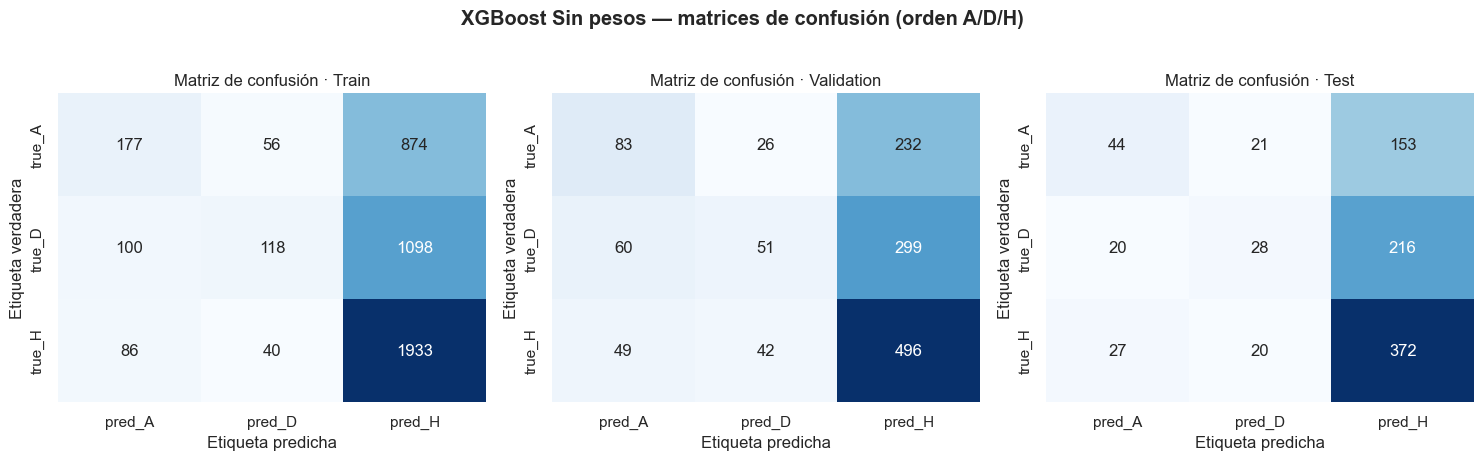

In [10]:
resultados_simple = {
    'Train':      evaluar_split_xgb(xgb_simple, 'XGB', 'Train',      X_train, y_train),
    'Validation': evaluar_split_xgb(xgb_simple, 'XGB', 'Validation', X_val,   y_val),
    'Test':       evaluar_split_xgb(xgb_simple, 'XGB', 'Test',       X_test,  y_test),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nombre, res) in zip(axes, resultados_simple.items()):
    cm = np.array(res['confusion_matrix'])
    graficar_matriz_confusion(cm, LABELS, nombre, ax=ax)
plt.suptitle('XGBoost Sin pesos — matrices de confusión (orden A/D/H)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


Top features (XGB sin pesos):
prob_h               0.073243
match_uncertainty    0.058283
away_gd_pre          0.037503
away_elo_pre         0.031879
away_gc_10           0.031366
home_mv              0.031355
away_gc_5            0.031145
home_gf_5            0.031138
home_ppg_10          0.030908
home_pos_pre         0.030900
away_ppg_3           0.030490
home_gd_pre          0.030307
away_mv              0.030230
away_pts_pre         0.030190
away_gc_3            0.030112
home_elo_pre         0.029967
away_rest_days       0.029798
home_gc_10           0.029620
away_gf_3            0.029343
away_gf_10           0.028611
home_rest_days       0.028497
away_ppg_10          0.028267
home_gf_3            0.028057
home_pts_pre         0.027694
home_ppg_5           0.026421
away_gf_5            0.026400
home_gf_10           0.026245
away_pos_pre         0.026125
home_gc_5            0.025010
home_gc_3            0.024796
away_ppg_5           0.024627
home_ppg_3           0.021475
dtype: flo

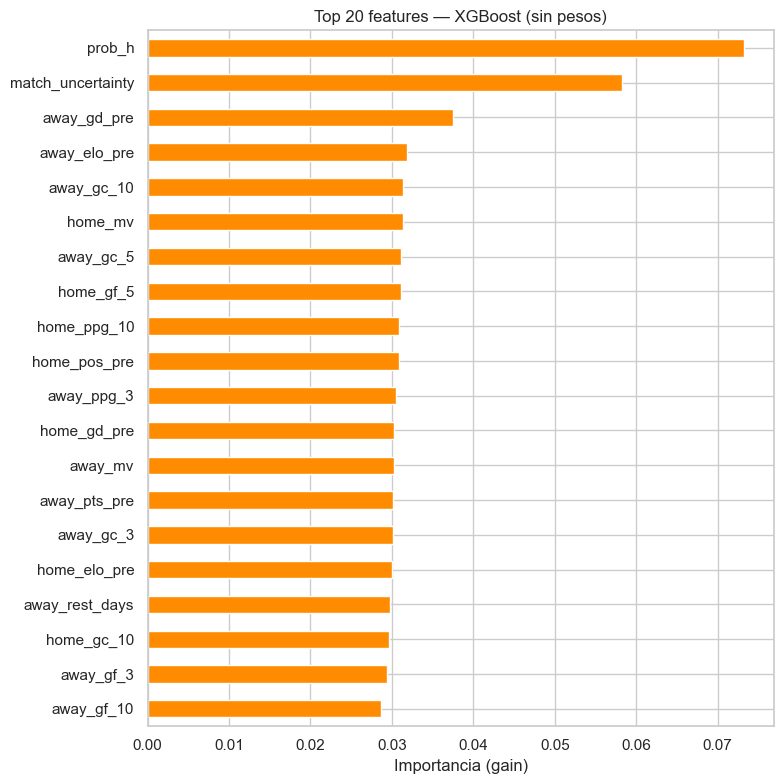

In [11]:
importancias = pd.Series(
    xgb_simple.feature_importances_,
    index=FEATURE_COLS,
).sort_values(ascending=False)

print("Top features (XGB sin pesos):")
print(importancias)

fig, ax = plt.subplots(figsize=(8, 8))
importancias.head(20).iloc[::-1].plot.barh(ax=ax, color='darkorange')
ax.set_title('Top 20 features — XGBoost (sin pesos)')
ax.set_xlabel('Importancia (gain)')
plt.tight_layout()
plt.show()


In [12]:
joblib.dump(xgb_balanced, MODELS_DIR / 'xgboost_balanced.pkl')
joblib.dump(xgb_simple, MODELS_DIR / 'xgboost_simple.pkl')

['/Users/pedrosarm/Desktop/TFM/Code/notebooks/models/xgboost_simple.pkl']